In [32]:
# === 1. 导入 ===
import os
import csv
import numpy as np
import mindspore as ms
from mindspore import nn, ops, Tensor
from mindspore.train import Model, Accuracy
from mindspore.nn import SoftmaxCrossEntropyWithLogits
from mindspore.dataset import GeneratorDataset

ms.set_context(mode=ms.GRAPH_MODE, device_target="Ascend")  # 或 "CPU"

# === 2. 加载数据 ===
with open('iris.data') as f:
    data = list(csv.reader(f, delimiter=','))
data = [row for row in data if len(row) == 5]

label_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
X = np.array([[float(x) for x in row[:-1]] for row in data], dtype=np.float32)
Y = np.array([label_map[row[-1]] for row in data], dtype=np.int32)

# === 3. 划分数据 ===
np.random.seed(42)
indices = np.random.permutation(150)
train_idx, test_idx = indices[:120], indices[120:]
X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

# === 4. 创建 Dataset（每次训练前都要新创建！）===
train_data = list(zip(X_train, Y_train))
ds_train = GeneratorDataset(train_data, ['x', 'y'], shuffle=True).batch(32, drop_remainder=True)

test_data = list(zip(X_test, Y_test))
ds_test = GeneratorDataset(test_data, ['x', 'y'], shuffle=False).batch(32)

# === 5. 模型 ===
net = nn.Dense(4, 3)
loss_fn = SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
optimizer = nn.SGD(net.trainable_params(), learning_rate=0.1)

model = Model(net, loss_fn, optimizer, metrics={"Accuracy": Accuracy()})

# === 6. 训练 ===
print("开始训练...")
model.train(
    epoch=10,
    train_dataset=ds_train,
    callbacks=[ms.train.LossMonitor(per_print_times=1)],
    dataset_sink_mode=False
)

# === 7. 评估 ===
acc = model.eval(ds_test, dataset_sink_mode=False)
print("Test Accuracy:", acc)



开始训练...


[WARNING] DEVICE(3907,ffffa9a710b0,python):2025-11-03-20:51:19.633.222 [mindspore/ccsrc/plugin/device/ascend/hal/hardware/ge_graph_executor.cc:1258] RunInitGraph] Can not find init_subgraph.kernel_graph_3 sub graph, don't need data init subgraph in INFER mode.


epoch: 1 step: 1, loss is 2.4405455589294434
epoch: 1 step: 2, loss is 1.1097215414047241
epoch: 1 step: 3, loss is 1.011535882949829
epoch: 2 step: 1, loss is 1.093933343887329
epoch: 2 step: 2, loss is 0.9100291728973389
epoch: 2 step: 3, loss is 0.8762744665145874
epoch: 3 step: 1, loss is 1.0133789777755737
epoch: 3 step: 2, loss is 1.0672922134399414
epoch: 3 step: 3, loss is 0.9431465864181519
epoch: 4 step: 1, loss is 0.7978267669677734
epoch: 4 step: 2, loss is 0.8144274950027466
epoch: 4 step: 3, loss is 1.0596574544906616
epoch: 5 step: 1, loss is 1.1517183780670166
epoch: 5 step: 2, loss is 1.2827138900756836
epoch: 5 step: 3, loss is 0.9114621877670288
epoch: 6 step: 1, loss is 0.8135129809379578
epoch: 6 step: 2, loss is 0.7794929146766663
epoch: 6 step: 3, loss is 0.551753044128418
epoch: 7 step: 1, loss is 0.6212079524993896
epoch: 7 step: 2, loss is 0.862156867980957
epoch: 7 step: 3, loss is 0.9530808329582214
epoch: 8 step: 1, loss is 0.5655026435852051
epoch: 8 step:

[WARNING] DEVICE(3907,ffffa9a710b0,python):2025-11-03-20:51:19.988.033 [mindspore/ccsrc/plugin/device/ascend/hal/hardware/ge_graph_executor.cc:1258] RunInitGraph] Can not find init_subgraph.kernel_graph_4 sub graph, don't need data init subgraph in INFER mode.


Test Accuracy: {'Accuracy': 0.8333333333333334}


[WARNING] DEVICE(3907,ffffa9a710b0,python):2025-11-03-20:52:28.805.195 [mindspore/ccsrc/plugin/device/ascend/hal/hardware/ge_graph_executor.cc:1258] RunInitGraph] Can not find init_subgraph.kernel_graph_5 sub graph, don't need data init subgraph in INFER mode.


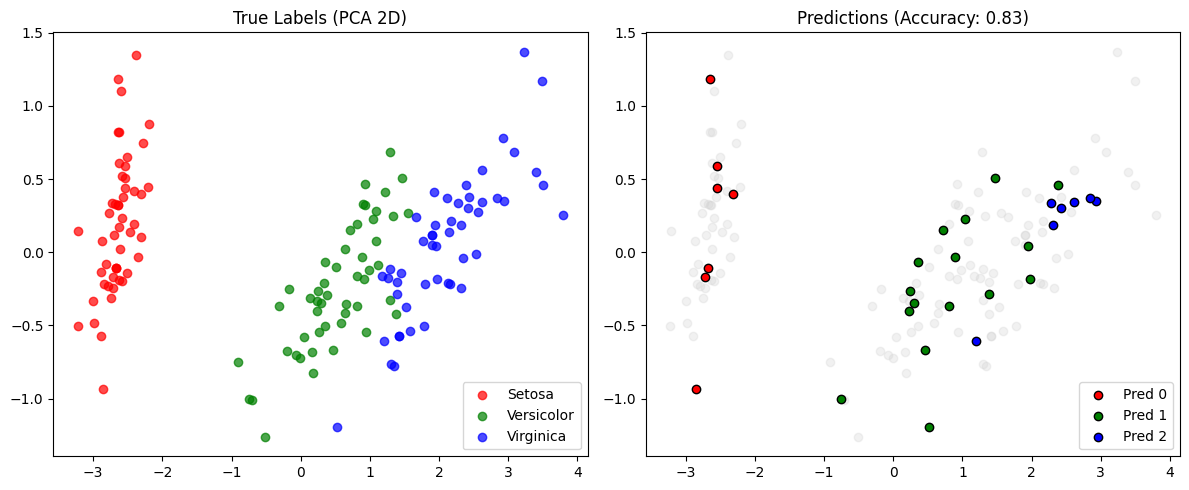

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 使用 PCA 将 4D 数据降到 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 获取训练集和测试集在 PCA 空间中的坐标
X_train_pca = X_pca[train_idx]
X_test_pca = X_pca[test_idx]

# 2. 可视化真实标签
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i, label in enumerate(['Setosa', 'Versicolor', 'Virginica']):
    idx = Y == i
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=colors[i], label=label, alpha=0.7)
plt.title('True Labels (PCA 2D)')
plt.legend()

# 3. 可视化预测结果
plt.subplot(1, 2, 2)
logits = net(Tensor(X_test)).asnumpy()
preds = np.argmax(logits, axis=1)

# 画出所有数据点（灰色背景）
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='lightgray', alpha=0.3)

# 高亮测试集预测结果
for i in range(3):
    idx = test_idx[preds == i]
    if len(idx) > 0:
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=colors[i], label=f'Pred {i}', edgecolors='k')
plt.title(f'Predictions (Accuracy: {acc["Accuracy"]:.2f})')
plt.legend()

plt.tight_layout()
plt.show()
